# Simple powder-pattern refinement

This notebook does exactly one job:

1. load one starting structure from a CIF;
2. load one measured pattern from an XY or XYE file;
3. refine ordinary profile and unit-cell parameters;
4. show the fitted pattern and refined values.

The included files are a synthetic example. To use your own data, change only the paths and wavelength in the first code cell.


## 1. Choose the files

A two-column `.xy` file should contain `2theta intensity`. A three-column `.xye` file should contain `2theta intensity sigma`. BraggCalculator accepts either form with the same loader. If sigma is absent, it estimates counting uncertainty from the intensity.


In [4]:
from importlib.resources import files
from pathlib import Path

import matplotlib.pyplot as plt
from IPython.display import display
from pymatgen.core import Structure

from braggcalculator import (
    DiffractionDataset,
    RefinementPolicy,
    RefinementSession,
)

# Replace these three values with your own CIF, XY/XYE, and wavelength.
EXAMPLE = Path(str(files("braggcalculator") / "tutorial_data"))
MODEL_FILE = EXAMPLE / "model-a.cif"
XY_FILE = EXAMPLE / "pattern.xye"
WAVELENGTH_ANGSTROM = 1.5406  # Cu K-alpha

print("Model file:", MODEL_FILE.name)
print("Pattern file:", XY_FILE.name)


Model file: model-a.cif
Pattern file: pattern.xye


## 2. Load the starting model and measured pattern

The structure supplies the starting unit cell and atoms. The dataset supplies the measured intensity and its uncertainty. Nothing is refined yet.


Formula: NaSiO2
Atoms in starting model: 4
Measured points: 801
Measured range: 18.00 to 82.00 degrees 2theta


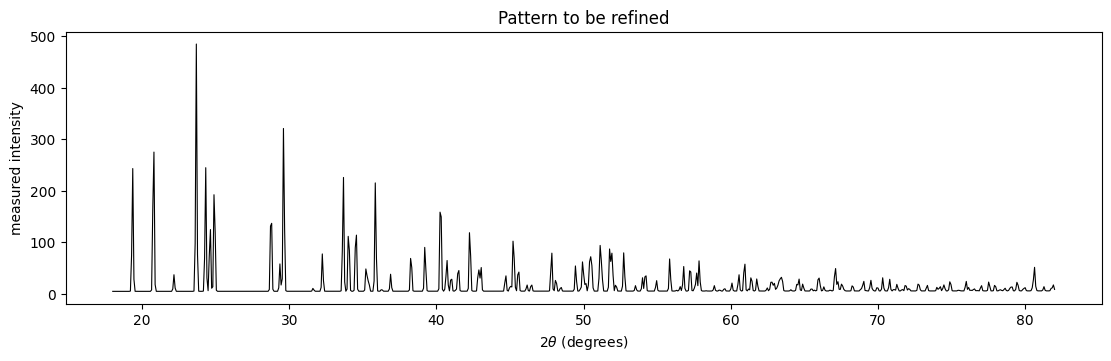

In [5]:
model = Structure.from_file(MODEL_FILE)
data = DiffractionDataset.from_xye(
    XY_FILE,
    wavelength=WAVELENGTH_ANGSTROM,
    radiation="xray",
)

print("Formula:", model.composition.reduced_formula)
print("Atoms in starting model:", len(model))
print("Measured points:", len(data.coordinate))
print(f"Measured range: {data.coordinate[0]:.2f} to {data.coordinate[-1]:.2f} degrees 2theta")

fig, ax = plt.subplots(figsize=(11, 3.5), constrained_layout=True)
ax.plot(data.coordinate, data.intensity, color="black", linewidth=0.8)
ax.set(
    xlabel=r"$2\theta$ (degrees)",
    ylabel="measured intensity",
    title="Pattern to be refined",
)
plt.show()


## 3. Refine

The quick policy refines, in stages:

- intensity scale and background;
- zero-angle offset and peak shape;
- unit-cell parameters allowed by the structure symmetry.

Atomic coordinates are deliberately kept fixed in this first tutorial. That is a safer starting point and makes the result easier to understand.


In [6]:
policy = RefinementPolicy.quick(refine_coordinates=False)
session = RefinementSession(data, [model], names=["starting model"])
result = session.run(policy)
fit = result.candidates[0]

print("Refinement finished.")
print(f"Rwp: {100 * fit.r_wp:.2f}%")


Refinement finished.
Rwp: 2.47%


## 4. Look at the fit

The upper plot overlays the measured and calculated patterns. The lower plot is `measured - calculated`. A good fit has overlapping curves and a small residual without repeated peak-shaped errors.


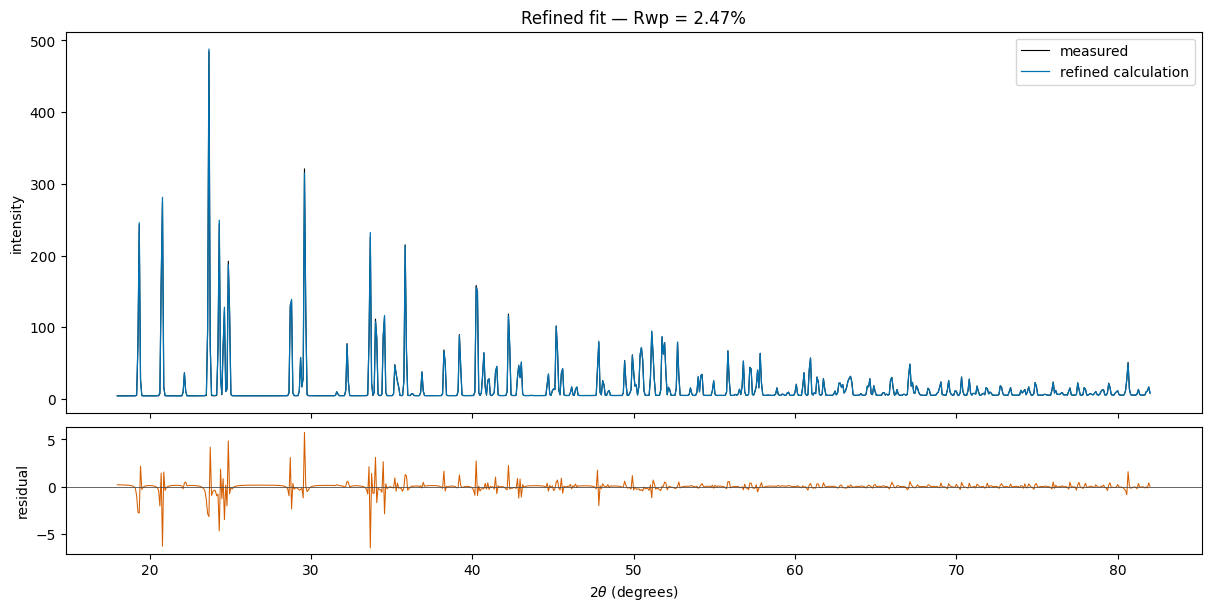

In [7]:
fig, axes = plt.subplots(
    2, 1, figsize=(12, 6), sharex=True,
    gridspec_kw={"height_ratios": [3, 1]}, constrained_layout=True,
)
axes[0].plot(data.coordinate, data.intensity, color="black", linewidth=0.8, label="measured")
axes[0].plot(data.coordinate, fit.calculated, color="#0072B2", linewidth=0.9, label="refined calculation")
axes[0].set(ylabel="intensity", title=f"Refined fit — Rwp = {100 * fit.r_wp:.2f}%")
axes[0].legend()
axes[1].plot(data.coordinate, fit.residual, color="#D55E00", linewidth=0.75)
axes[1].axhline(0, color="0.3", linewidth=0.6)
axes[1].set(xlabel=r"$2\theta$ (degrees)", ylabel="residual")
plt.show()


## 5. Read the refined values

The table compares the starting and refined unit cell. `Rwp` summarizes profile agreement; smaller is better for the same dataset and weighting, but it is not proof that the structural model is unique. Background and peak-shape terms were also fitted internally; they remain available in `fit.physical_parameters` if you need them later.


In [8]:
parameters = fit.physical_parameters
starting_cell = {
    "a": model.lattice.a, "b": model.lattice.b, "c": model.lattice.c,
    "alpha": model.lattice.alpha, "beta": model.lattice.beta,
    "gamma": model.lattice.gamma,
}
refined_cell = parameters["cell_parameters"]
display([
    {
        "parameter": name,
        "starting value": starting_cell[name],
        "refined value": refined_cell[name],
    }
    for name in ("a", "b", "c", "alpha", "beta", "gamma")
])
print(f"Zero shift: {parameters['zero_shift']:.5f} degrees")
print(f"Final Rwp: {100 * fit.r_wp:.2f}%")


[{'parameter': 'a', 'starting value': 4.8, 'refined value': 4.800241429280075},
 {'parameter': 'b',
  'starting value': 5.400000000000001,
  'refined value': 5.400295875650187},
 {'parameter': 'c', 'starting value': 6.2, 'refined value': 6.200382088890221},
 {'parameter': 'alpha',
  'starting value': 79.0,
  'refined value': 79.00035576825896},
 {'parameter': 'beta',
  'starting value': 84.0,
  'refined value': 84.00033812277529},
 {'parameter': 'gamma',
  'starting value': 73.0,
  'refined value': 72.99932360599463}]

Zero shift: 0.00461 degrees
Final Rwp: 2.47%


## Done

You loaded one model and one powder pattern, refined the ordinary profile and unit-cell parameters, and inspected the result.
